# 🧬 universal-survival-engine
## 🔬 DAE vs GCN+DAE — Multi-Dataset Representation Comparison
**Author:** Bjoernar KK | **Version:** 1.3 (config-portable edition)

---

### What this notebook does
A head-to-head ablation study comparing two unsupervised representation
learning approaches across three real TCGA cancer cohorts:

| Model | Architecture | Graph? |
|-------|-------------|--------|
| **DAE** | MLP encoder → latent → decoder | ✗ |
| **GCN + DAE** | k-NN adjacency GCN → latent → decoder | ✓ |

Both models have **matched parameter counts** (same hidden width).  
The study asks: *does adding a patient-similarity graph improve the
quality of the latent space as measured by reconstruction MSE,
silhouette score, and concordance with risk labels?*

**Three datasets — all real TCGA genomics (same feature space, comparable MSE):**

| # | Dataset | Cancer | N | Features | Biology |
|---|---------|--------|---|----------|---------|
| 1 | TCGA-LGG  | Brain lower-grade glioma      | ~516 | top-3000 HVGs | IDH1/IDH2/ATRX |
| 2 | TCGA-KIRC | Kidney renal cell carcinoma   | ~530 | top-3000 HVGs | VHL/mTOR/PI3K  |
| 3 | TCGA-LUAD | Lung adenocarcinoma           | ~500 | top-3000 HVGs | KRAS/EGFR/TP53 |

> **v1.0 → v1.3 changes:**  
> v1.0/v1.1 used GBSG2 and Rossi as synthetic stand-ins; replaced in v1.2 by real
> TCGA-KIRC and TCGA-LUAD.  
> **v1.3:** all hyperparameters (`k_nn`, `hidden_dim`, `latent_dim`, `epochs`,
> `lr`, `noise_factor`) now read exclusively from `config.yaml → nb05:` section.
> Cohort list, raw-data path, and all output directories are also config-driven.
> No magic numbers remain in the notebook.

---

**Reads** (all from `data/raw/` — must exist before running):
```
TCGA-LGG.star_fpkm.tsv    TCGA-LGG.survival.tsv
TCGA-KIRC.star_fpkm.tsv   TCGA-KIRC.survival.tsv
TCGA-LUAD.star_fpkm.tsv   TCGA-LUAD.survival.tsv
```
Use `tcga_download_resumable.py` to obtain KIRC and LUAD if not yet downloaded.

**Writes** (paths from `config.yaml → output:`):
```
embeddings/dae_gcn_fusion/{cid}_dae_latents.csv
embeddings/dae_gcn_fusion/{cid}_gcndae_latents.csv
results/figures/daegcn_*.png
```

### Notebook map
| Cell | Task |
|------|------|
| 1 | Verify all 6 TSV files exist |
| 2 | Environment setup |
| 3 | Config and paths |
| 4 | Model architectures and shared utilities |
| 5 | TCGA-LGG: load, preprocess, train |
| 6 | TCGA-LGG: figures |
| 7 | TCGA-KIRC: load, preprocess, train |
| 8 | TCGA-KIRC: figures |
| 9 | TCGA-LUAD: load, preprocess, train |
| 10 | TCGA-LUAD: figures |
| 11 | Cross-cohort summary figures |
| 12 | Master summary table |


### Cell 1 — Verify All 6 TCGA Files Exist

In [1]:
# ==============================================================================
# CELL 1: VERIFY ALL TCGA FILES LISTED IN config.yaml → cohorts
# Hard stop with clear message if anything is missing.
# ==============================================================================
import os
from pathlib import Path

_cfg_path = Path('config.yaml')
if not _cfg_path.exists():
    raise FileNotFoundError("'config.yaml' missing from workspace root.")

import yaml as _yaml
with open(_cfg_path, encoding='utf-8') as _f:
    _cfg = _yaml.safe_load(_f)

_raw = Path.cwd() / _cfg.get('data', {}).get('raw_dir', 'data/raw')
_cohorts = _cfg.get('cohorts', [])
if not _cohorts:
    raise ValueError("config.yaml contains no cohorts.")

REQUIRED = [
    fname
    for c in _cohorts
    for fname in (c['expression_file'], c['survival_file'])
]

print(f'Checking {_raw.resolve()}')
print(f'Cohorts  : {[c["name"] for c in _cohorts]}')
print()
missing = []
for fname in REQUIRED:
    fp = _raw / fname
    if fp.exists():
        print(f'  OK       {fname:<40}  {fp.stat().st_size/1e6:7.1f} MB')
    else:
        print(f'  MISSING  {fname}')
        missing.append(fname)

if missing:
    shorts = [c['short'] for c in _cohorts
              if c['expression_file'] in missing or c['survival_file'] in missing]
    raise FileNotFoundError(
        f'\n{len(missing)} file(s) missing.\n'
        + '\n'.join(f'  {f}' for f in missing)
        + '\n\nRun: '
        + '  '.join(f'python tcga_download_resumable.py --cohort {s.upper()}' for s in shorts)
    )
print()
print(f'All {len(REQUIRED)} files present. Proceed to Cell 2.')


Checking D:\JupyterWork\NB04\data\raw
Cohorts  : ['TCGA-LGG', 'TCGA-KIRC', 'TCGA-LUAD']

  OK       TCGA-LGG.star_fpkm.tsv                      406.3 MB
  OK       TCGA-LGG.survival.tsv                         0.0 MB
  OK       TCGA-KIRC.star_fpkm.tsv                     204.3 MB
  OK       TCGA-KIRC.survival.tsv                        0.0 MB
  OK       TCGA-LUAD.star_fpkm.tsv                     199.0 MB
  OK       TCGA-LUAD.survival.tsv                        0.0 MB

All 6 files present. Proceed to Cell 2.


### Cell 2 — Environment Setup & Deterministic Seeding

In [2]:
# ==============================================================================
# CELL 2: ENVIRONMENT
# ==============================================================================
import gc
import os
import random
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

warnings.filterwarnings('ignore')
SEED = 42

def enforce_determinism(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

enforce_determinism(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device  : {device}')
print(f'Python  : {platform.python_version()}')
print(f'PyTorch : {torch.__version__}')
print(f'Seed    : {SEED}')

RISK_COLORS = {0: '#d62728', 1: '#ff7f0e', 2: '#1f77b4'}
RISK_LABELS = {0: 'High risk', 1: 'Intermediate', 2: 'Low risk'}
# COHORT_COLORS built from config in Cell 3 after cfg is loaded.
# Fallback palette used here if Cell 3 hasn't run yet (shouldn't happen in Restart & Run All).
COHORT_COLORS = {}   # populated by Cell 3


Device  : cpu
Python  : 3.12.3
PyTorch : 2.12.0+cpu
Seed    : 42


### Cell 3 — Config and Paths

In [3]:
# ==============================================================================
# CELL 3: CONFIG AND PATHS
# All hyperparameters come from config.yaml → nb05:
# Falls back to training.* / model.* for params not overridden in nb05.
# ==============================================================================
CONFIG_PATH = Path('config.yaml')
if not CONFIG_PATH.exists():
    raise FileNotFoundError("'config.yaml' missing from workspace root.")

with open(CONFIG_PATH, encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

SEED = cfg.get('training', {}).get('seed', SEED)
enforce_determinism(SEED)
print(f"Config  : {cfg['project']['name']} v{cfg['project']['version']}")

BASE_DIR   = Path.cwd()
data_cfg   = cfg.get('data',          {})
pp_cfg     = cfg.get('preprocessing', {})
model_cfg  = cfg.get('model',         {})
train_cfg  = cfg.get('training',      {})
nb05_cfg   = cfg.get('nb05',          {})   # ← NB05-specific overrides
out_cfg    = cfg.get('output',        {})

# ── Hyperparameters — nb05.* takes priority, falls back to shared sections ────
TARGET_GENES = pp_cfg.get('variance_filter_top_n', 3000)
LATENT_DIM   = nb05_cfg.get('latent_dim',   model_cfg.get('latent_dim',          64))
HIDDEN_DIM   = nb05_cfg.get('hidden_dim',                                         32)
K_NN         = nb05_cfg.get('k_nn',                                               15)
EPOCHS       = nb05_cfg.get('epochs',       train_cfg.get('epochs',               40))
LR           = nb05_cfg.get('lr',           train_cfg.get('lr',                0.0005))
NOISE_FACTOR = nb05_cfg.get('noise_factor', train_cfg.get('noise_factor',       0.25))

# ── Output directories — from config.output ───────────────────────────────────
PIPELINE_STAGE = 'NB05'
RAW_DIR        = BASE_DIR / data_cfg.get('raw_dir', 'data/raw')
CHECKPOINT_DIR = BASE_DIR / out_cfg.get('checkpoint_dir', 'checkpoints') / PIPELINE_STAGE
EMBEDDINGS_DIR = BASE_DIR / out_cfg.get('embeddings_dir', 'embeddings')  / PIPELINE_STAGE
FIGURES_DIR    = (BASE_DIR / out_cfg.get('results_dir',    'results')
                           / PIPELINE_STAGE
                           / out_cfg.get('figures_subdir', 'figures'))
for d in [CHECKPOINT_DIR, EMBEDDINGS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Cohort list — driven entirely by config.cohorts ───────────────────────────
COHORT_CONFIGS = [
    {
        'name' : c['name'],
        'label': c['label'],
        'cid'  : c['short'],
        'expr' : RAW_DIR / c['expression_file'],
        'surv' : RAW_DIR / c['survival_file'],
    }
    for c in cfg.get('cohorts', [])
]
if not COHORT_CONFIGS:
    raise ValueError("config.yaml contains no cohorts.")

# ── Cohort colour palette — config-driven, no hardcoded names ─────────────────
_PALETTE = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#8c564b']
COHORT_COLORS = {
    c['name']: _PALETTE[idx % len(_PALETTE)]
    for idx, c in enumerate(COHORT_CONFIGS)
}

print(f'  Cohorts     : {[c["name"] for c in COHORT_CONFIGS]}')
print(f'  Raw data    : {RAW_DIR}')
print(f'  Checkpoints : {CHECKPOINT_DIR}')
print(f'  Embeddings  : {EMBEDDINGS_DIR}')
print(f'  Figures     : {FIGURES_DIR}')
print(f'  target_genes={TARGET_GENES} | latent={LATENT_DIM} | hidden={HIDDEN_DIM}'
      f' | epochs={EPOCHS} | noise={NOISE_FACTOR} | k_nn={K_NN} | lr={LR}')

def savefig(name, dpi=150):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'  Saved -> {path.name}')
    plt.show()
    plt.close()


Config  : universal-survival-engine v3.3
  Cohorts     : ['TCGA-LGG', 'TCGA-KIRC', 'TCGA-LUAD']
  Raw data    : D:\JupyterWork\NB04\data\raw
  Checkpoints : D:\JupyterWork\NB04\checkpoints\NB05
  Embeddings  : D:\JupyterWork\NB04\embeddings\NB05
  Figures     : D:\JupyterWork\NB04\results\NB05\figures
  target_genes=3000 | latent=64 | hidden=32 | epochs=40 | noise=0.25 | k_nn=15 | lr=0.0005


### Cell 4 — Model Architectures & Shared Utilities

All dataset-handling is unified in `load_tcga_cohort()` — one function used by
all three cohorts, identical RAM-efficient pattern throughout:
read → orient → version-strip → variance-filter → `del` raw frame → align survival.


In [4]:
# ==============================================================================
# CELL 4: MODELS AND SHARED UTILITIES
# ==============================================================================

# ── Models ────────────────────────────────────────────────────────────────────
class DAE(nn.Module):
    """Denoising Auto-Encoder (no graph)."""
    def __init__(self, in_dim, latent_dim, hidden=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, in_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
    def forward(self, x, adj):
        return self.linear(torch.mm(adj, x))


class GraphFusionDAE(nn.Module):
    """Two-layer GCN encoder + symmetric MLP decoder. Matched capacity to DAE."""
    def __init__(self, in_dim, latent_dim, hidden=32):
        super().__init__()
        self.gcn1    = GCNLayer(in_dim, hidden)
        self.gcn2    = GCNLayer(hidden, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, in_dim),
        )
    def forward(self, x, adj):
        h = F.relu(self.gcn1(x, adj))
        z = self.gcn2(h, adj)
        return z, self.decoder(z)


# ── Graph builder ─────────────────────────────────────────────────────────────
def build_knn_adj(X_scaled, k=15):
    """Symmetric normalised k-NN adjacency: D^-0.5 (A+I) D^-0.5.
    Reuses sim array in-place — avoids a second full N×N allocation.
    """
    sim = cosine_similarity(X_scaled)
    np.fill_diagonal(sim, -1)
    for i in range(len(sim)):
        top_k = np.argsort(sim[i])[-k:]
        mask  = np.ones(len(sim), dtype=bool)
        mask[top_k] = False
        sim[i, mask] = 0.0
    adj = np.maximum(sim, sim.T); del sim
    np.fill_diagonal(adj, 1.0)
    deg   = adj.sum(1)
    d_inv = np.power(deg, -0.5, where=deg > 0, out=np.zeros_like(deg))
    norm  = (d_inv[:, None] * adj) * d_inv[None, :]
    del adj, d_inv
    return torch.tensor(norm, dtype=torch.float32)


# ── Risk labels ───────────────────────────────────────────────────────────────
def make_risk_labels(times, events):
    """3-class: 0=high (early event), 1=intermediate, 2=low."""
    ev_times = times[events == 1]
    p33, p67 = np.percentile(ev_times, 33), np.percentile(ev_times, 67)
    lbl = np.ones(len(times), dtype=int)
    lbl[(events == 1) & (times < p33)] = 0
    lbl[times >= p67] = 2
    return lbl


# ── TCGA loader ───────────────────────────────────────────────────────────────
def _strip_version(ensg):
    return str(ensg).split('.')[0]

def _trim_barcode(s):
    s = str(s).strip().replace('.', '-').upper()
    return '-'.join(s.split('-')[:3]) if s.startswith('TCGA') else s

def load_tcga_cohort(name, expr_path, surv_path, top_n=3000):
    """
    RAM-efficient TCGA loader shared by all three cohorts.
    Peak RAM = one full TSV at a time (~120 MB float32).
    After variance-filter: keeps only top_n genes (~6 MB per cohort).
    """
    print(f'Loading {name} ...')

    # ── expression ────────────────────────────────────────────────────────────
    _fsize = expr_path.stat().st_size / 1e6
    if _fsize < 1.0:
        raise RuntimeError(
            f'[{name}] Expression file too small ({_fsize:.2f} MB) — likely a '
            'partial download. Re-run: python tcga_download_resumable.py '
            f'--cohort {name.split("-")[1]}'
        )
    print(f'  Loading  : {expr_path.name}  ({_fsize:.1f} MB)')
    expr = pd.read_csv(expr_path, sep='\t', index_col=0)
    if expr.shape[0] > expr.shape[1]:      # genes×samples → samples×genes
        expr = expr.T
    expr.columns = pd.Index([_strip_version(c) for c in expr.columns])
    expr = expr.loc[:, ~expr.columns.duplicated(keep='first')]
    expr.index = pd.Index([_trim_barcode(i) for i in expr.index])
    expr = expr[~expr.index.duplicated(keep='first')]

    # ── RAM-safe column filtering ──────────────────────────────────────────────
    # select_dtypes().dropna(axis=1) on a full-width frame (60k+ cols) creates
    # a full copy before dropping — peak = 2× frame size → MemoryError.
    # Fix: identify keep-columns with cheap masks first, then slice once.
    _num_cols  = [c for c in expr.columns
                  if pd.api.types.is_numeric_dtype(expr[c])]
    _notna_cols = [c for c in _num_cols
                   if expr[c].notna().all()]
    expr = expr[_notna_cols]          # single in-place slice, no copy overhead
    del _num_cols, _notna_cols

    # variance-filter BEFORE keeping anything (key RAM guard)
    top_genes = expr.astype(np.float32).var(axis=0).nlargest(top_n).index.tolist()
    expr_filt = expr[top_genes].astype(np.float32)
    del expr; gc.collect()          # free full-width frame immediately

    # ── survival ──────────────────────────────────────────────────────────────
    clin = pd.read_csv(surv_path, sep='\t')
    clin['sample'] = [_trim_barcode(i) for i in clin['sample'].astype(str)]
    clin = clin.set_index('sample')
    tc = next((c for c in ['OS.time','survival_time','time','days_to_death']
               if c in clin.columns), None)
    ec = None
    for _ec in ['OS','event','status','vital_status','OS.event','DSS','PFI','DFI']:
        if _ec not in clin.columns: continue
        _col = clin[_ec]
        if _col.dtype == object or str(_col.dtype) == 'string':
            _dead = {'deceased','dead','1','true','yes'}
            _col = _col.astype(str).str.strip().str.lower().isin(_dead).astype(np.float32)
        else:
            _col = pd.to_numeric(_col, errors='coerce').fillna(0).astype(np.float32)
        if (_col == 1).any():
            ec = _ec; clin = clin.copy(); clin[_ec] = _col; break
    if tc is None or ec is None:
        raise ValueError(
            f'[{name}] No usable time/event columns found.\n'
            f'  Columns: {clin.columns.tolist()}'
        )

    common    = expr_filt.index.intersection(clin.index)
    expr_filt = expr_filt.loc[common]
    surv      = clin.loc[common, [tc, ec]].astype(float)
    valid     = surv[tc].notna() & surv[ec].notna() & (surv[tc] > 0)
    expr_filt = expr_filt.loc[valid].dropna(axis=1)
    surv      = surv.loc[valid]

    X   = expr_filt.values.astype(np.float32)
    t   = surv[tc].values.astype(np.float32)
    e   = surv[ec].values.astype(np.float32)
    del expr_filt, surv, clin; gc.collect()

    print(f'  {name}: {len(t)} patients | {X.shape[1]:,} genes | '
          f'{int(e.sum())} events ({100*e.mean():.1f}%) | '
          f'RAM: {X.nbytes/1e6:.1f} MB')
    return X, t, e


# ── Training ──────────────────────────────────────────────────────────────────
def train_models(X_scaled, X_noisy, adj, latent_dim=64, epochs=40, lr=5e-3, hidden=None):
    """
    Train DAE and GraphFusionDAE with identical init for fair comparison.
    Returns compact result dict; GPU memory freed before return.
    """
    hidden = hidden if hidden is not None else 32  # sentinel: prefer explicit arg from config
    enforce_determinism(SEED)
    in_dim = X_scaled.shape[1]
    X_t    = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    Xn_t   = torch.tensor(X_noisy,  dtype=torch.float32).to(device)
    A_t    = adj.to(device)
    mse_fn = nn.MSELoss()

    dae    = DAE(in_dim, latent_dim, hidden).to(device)
    fusion = GraphFusionDAE(in_dim, latent_dim, hidden).to(device)
    opt_d  = torch.optim.Adam(dae.parameters(),    lr=lr)
    opt_f  = torch.optim.Adam(fusion.parameters(), lr=lr)

    losses_d, losses_f = [], []
    for _ in range(epochs):
        dae.train(); fusion.train()

        opt_d.zero_grad()
        _, r = dae(Xn_t)
        l = mse_fn(r, X_t); l.backward(); opt_d.step()
        losses_d.append(l.item())

        opt_f.zero_grad()
        _, r2 = fusion(Xn_t, A_t)
        l2 = mse_fn(r2, X_t); l2.backward(); opt_f.step()
        losses_f.append(l2.item())

    dae.eval(); fusion.eval()
    with torch.no_grad():
        z_d, r_d  = dae(X_t)
        z_f, r_f  = fusion(X_t, A_t)

    result = {
        'z_dae':           z_d.cpu().numpy(),
        'z_fusion':        z_f.cpu().numpy(),
        'recon_dae':       r_d.cpu().numpy(),
        'recon_fusion':    r_f.cpu().numpy(),
        'losses_dae':      losses_d,
        'losses_fusion':   losses_f,
        'X_t':             X_t.cpu().numpy(),
        # state dicts kept for checkpoint saving — deleted after save in cohort cell
        'state_dae':       {k: v.cpu().clone() for k, v in dae.state_dict().items()},
        'state_fusion':    {k: v.cpu().clone() for k, v in fusion.state_dict().items()},
        'model_config':    {'in_dim': in_dim, 'latent_dim': latent_dim, 'hidden': hidden},
    }
    del dae, fusion, opt_d, opt_f, X_t, Xn_t, A_t, z_d, z_f, r_d, r_f
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()
    return result


# ── Metrics ───────────────────────────────────────────────────────────────────
def concordance_proxy(z_np, labels):
    pc1 = PCA(n_components=1, random_state=SEED).fit_transform(z_np).ravel()
    r, _ = pearsonr(pc1, labels)
    return abs(r)

def compute_metrics(res, labels):
    mse_d = float(np.mean((res['recon_dae']    - res['X_t'])**2))
    mse_f = float(np.mean((res['recon_fusion'] - res['X_t'])**2))
    sil_d = float(silhouette_score(res['z_dae'],    labels))
    sil_f = float(silhouette_score(res['z_fusion'], labels))
    con_d = float(concordance_proxy(res['z_dae'],    labels))
    con_f = float(concordance_proxy(res['z_fusion'], labels))
    return mse_d, mse_f, sil_d, sil_f, con_d, con_f

def print_metrics(name, mse_d, mse_f, sil_d, sil_f, con_d, con_f):
    print(f'{"="*52}')
    print(f'{name} RESULTS')
    print(f'{"Metric":<28} {"DAE":>8} {"GCN+DAE":>10}')
    print(f'{"-"*52}')
    print(f'{"MSE":<28} {mse_d:>8.4f} {mse_f:>10.4f}')
    print(f'{"Silhouette":<28} {sil_d:>8.4f} {sil_f:>10.4f}')
    print(f'{"Concordance proxy":<28} {con_d:>8.4f} {con_f:>10.4f}')
    print(f'{"="*52}')

def save_embeddings(res, labels, times, events, cid):
    """Save full-cohort embeddings (scaler fit on all patients — representation only).
    NB05 is unsupervised; no train/test split exists, so held-out embeddings
    are not applicable. Label is explicit in filename and print for audit trail.
    """
    ld   = res['z_dae'].shape[1]
    cols = [f'z_{i}' for i in range(ld)]
    def _df(z):
        d = pd.DataFrame(z, columns=cols)
        d['survival_time'] = times
        d['event']         = events
        d['risk_label']    = labels
        return d
    p_dae = EMBEDDINGS_DIR / f'NB05_{cid}_dae_fullcohort_latents.csv'
    p_gcn = EMBEDDINGS_DIR / f'NB05_{cid}_gcndae_fullcohort_latents.csv'
    _df(res['z_dae']).to_csv(p_dae, index=False)
    _df(res['z_fusion']).to_csv(p_gcn, index=False)
    print(f'  📁 {p_dae.name}  (full-cohort scaler — representation only)')
    print(f'  📁 {p_gcn.name}  (full-cohort scaler — representation only)')

def plot_latent_space(res, labels, name, mse_d, mse_f, sil_d, sil_f, fig_suffix):
    node_colors = [RISK_COLORS[l] for l in labels]
    perp = min(30, len(res['z_dae']) // 4)
    z_dp = PCA(2, random_state=SEED).fit_transform(res['z_dae'])
    z_fp = PCA(2, random_state=SEED).fit_transform(res['z_fusion'])
    z_dt = TSNE(2, perplexity=perp, random_state=SEED, max_iter=1000).fit_transform(res['z_dae'])
    z_ft = TSNE(2, perplexity=perp, random_state=SEED, max_iter=1000).fit_transform(res['z_fusion'])
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    for ax, z2d, title, mse, sil in [
        (axes[0,0], z_dp, 'DAE — PCA',       mse_d, sil_d),
        (axes[0,1], z_fp, 'GCN+DAE — PCA',   mse_f, sil_f),
        (axes[1,0], z_dt, 'DAE — t-SNE',     mse_d, sil_d),
        (axes[1,1], z_ft, 'GCN+DAE — t-SNE', mse_f, sil_f),
    ]:
        ax.scatter(z2d[:,0], z2d[:,1], c=node_colors, alpha=0.7,
                   edgecolors='k', lw=0.25, s=30)
        ax.set(title=f'{title}\nMSE={mse:.4f}  Sil={sil:.3f}')
        ax.grid(True, ls='--', alpha=0.35)
    patches = [mpatches.Patch(color=RISK_COLORS[k], label=RISK_LABELS[k])
               for k in sorted(RISK_COLORS)]
    fig.legend(handles=patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f'{name} — Latent Space (perplexity={perp})', fontweight='bold')
    plt.tight_layout(); savefig(f'daegcn_{fig_suffix}_latent.png')
    del z_dp, z_fp, z_dt, z_ft; gc.collect()

def plot_km(res, labels, times, events, name, fig_suffix):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, model_name in zip(axes, ['DAE Alone', 'GCN + DAE']):
        for cls in [0, 1, 2]:
            mask = labels == cls
            if mask.sum() >= 5:
                KaplanMeierFitter().fit(
                    times[mask], event_observed=events[mask], label=RISK_LABELS[cls]
                ).plot_survival_function(ax=ax, ci_show=True, color=RISK_COLORS[cls])
        m0, m2 = labels == 0, labels == 2
        if m0.sum() >= 5 and m2.sum() >= 5:
            lr = logrank_test(times[m0], times[m2], events[m0], events[m2])
            ax.text(0.98, 0.02, f'Log-rank p={lr.p_value:.3f}',
                    transform=ax.transAxes, ha='right', va='bottom', fontsize=8)
        ax.set(title=f'{name} — {model_name}', xlabel='Days', ylabel='Survival P')
        ax.grid(True, ls='--', alpha=0.3)
    fig.suptitle(f'{name} — Kaplan-Meier by Risk Class', fontweight='bold')
    plt.tight_layout(); savefig(f'daegcn_{fig_suffix}_km.png')

def plot_recon_benefit(res, labels, name, fig_suffix):
    err_d = ((res['recon_dae']    - res['X_t'])**2).mean(axis=1)
    err_f = ((res['recon_fusion'] - res['X_t'])**2).mean(axis=1)
    delta = err_d - err_f
    order = np.argsort(delta)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(range(len(delta)), delta[order],
                color=[RISK_COLORS[labels[i]] for i in order], width=1.0)
    axes[0].axhline(0, color='k', lw=0.8)
    axes[0].set(title='Per-Patient MSE Improvement (DAE - GCN+DAE)',
                xlabel='Patient (sorted)', ylabel='MSE reduction (up = GCN+DAE better)')
    axes[1].bar([RISK_LABELS[k] for k in [0,1,2]],
                [delta[labels==k].mean() for k in [0,1,2]],
                color=[RISK_COLORS[k] for k in [0,1,2]])
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set(title='Mean MSE Improvement by Risk Class', ylabel='Mean MSE reduction')
    fig.suptitle(f'{name} — Graph Fusion Reconstruction Benefit', fontweight='bold')
    plt.tight_layout(); savefig(f'daegcn_{fig_suffix}_recon_benefit.png')
    del err_d, err_f, delta, order

def plot_heatmap(res, labels, times, name, fig_suffix):
    sort_idx = np.lexsort((times, labels))
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, z_np, title in zip(axes,
        [res['z_dae'][sort_idx], res['z_fusion'][sort_idx]],
        ['DAE — Latent', 'GCN+DAE — Latent']):
        im = ax.imshow(z_np, aspect='auto', cmap='coolwarm', interpolation='nearest')
        ax.set(title=title, xlabel='Latent Dim', ylabel='Patient (sorted by risk)')
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
        for b in np.where(np.diff(labels[sort_idx]))[0] + 1:
            ax.axhline(b - 0.5, color='yellow', lw=1.0, ls='--')
    fig.suptitle(f'{name} — Latent Heatmap (sorted by risk class)', fontweight='bold')
    plt.tight_layout(); savefig(f'daegcn_{fig_suffix}_heatmap.png')

print('All models, loaders, and plot helpers defined.')
print(f'  Architecture: in -> {HIDDEN_DIM} -> latent={LATENT_DIM} -> {HIDDEN_DIM} -> in  (both models)')


All models, loaders, and plot helpers defined.
  Architecture: in -> 32 -> latent=64 -> 32 -> in  (both models)


### Cell 5 — TCGA-LGG: Load, Preprocess, Build Graph & Train

In [5]:
# ==============================================================================
# CELL 3: TCGA-LGG — LOAD, PREPROCESS, BUILD GRAPH, TRAIN
# RAM pattern: load -> filter -> scale -> del raw -> build adj -> train -> del intermediates
# ==============================================================================
X1_raw, t1, e1 = load_tcga_cohort(
    'TCGA-LGG',
    COHORT_CONFIGS[0]['expr'],
    COHORT_CONFIGS[0]['surv'],
    top_n=TARGET_GENES,
)

scaler1    = StandardScaler()
X1_scaled  = scaler1.fit_transform(X1_raw)
del X1_raw; gc.collect()

X1_noisy = (X1_scaled
                  + NOISE_FACTOR * np.random.randn(*X1_scaled.shape).astype(np.float32))
labels1  = make_risk_labels(t1, e1)
A1       = build_knn_adj(X1_scaled, k=min(K_NN, len(X1_scaled)//4))

counts = np.bincount(labels1)
print('Risk label distribution (TCGA-LGG):')
for k, nm in RISK_LABELS.items():
    print(f'  Class {k} ({nm}): {counts[k]}')

res1 = train_models(X1_scaled, X1_noisy, A1,
                          latent_dim=LATENT_DIM, epochs=EPOCHS, lr=LR, hidden=HIDDEN_DIM)
del X1_noisy, A1; gc.collect()

mse1_d, mse1_f, sil1_d, sil1_f, con1_d, con1_f = \
    compute_metrics(res1, labels1)

print_metrics('TCGA-LGG', mse1_d, mse1_f,
              sil1_d, sil1_f, con1_d, con1_f)
save_embeddings(res1, labels1, t1, e1, 'lgg')

# ── Checkpoint: save both model weights before freeing res ────────────────
torch.save({
    'state_dae':    res1['state_dae'],
    'state_fusion': res1['state_fusion'],
    'model_config': res1['model_config'],
    'cohort':       'lgg',
    'pipeline_stage': PIPELINE_STAGE,
    'metrics': {
        'mse_dae':    mse1_d, 'mse_fusion':    mse1_f,
        'sil_dae':    sil1_d, 'sil_fusion':    sil1_f,
        'con_dae':    con1_d, 'con_fusion':    con1_f,
    },
}, CHECKPOINT_DIR / f'NB05_lgg_dae_gcn.pt')
print(f'  💾 NB05_lgg_dae_gcn.pt')
del res1['state_dae'], res1['state_fusion']; gc.collect()

n1_patients = len(X1_scaled)
n1_features = X1_scaled.shape[1]
del X1_scaled; gc.collect()


Loading TCGA-LGG ...
  Loading  : TCGA-LGG.star_fpkm.tsv  (406.3 MB)
  TCGA-LGG: 512 patients | 3,000 genes | 126 events (24.6%) | RAM: 6.1 MB
Risk label distribution (TCGA-LGG):
  Class 0 (High risk): 42
  Class 1 (Intermediate): 346
  Class 2 (Low risk): 124
TCGA-LGG RESULTS
Metric                            DAE    GCN+DAE
----------------------------------------------------
MSE                            0.9246     0.9190
Silhouette                    -0.0479    -0.0601
Concordance proxy              0.2152     0.2173
  📁 NB05_lgg_dae_fullcohort_latents.csv  (full-cohort scaler — representation only)
  📁 NB05_lgg_gcndae_fullcohort_latents.csv  (full-cohort scaler — representation only)
  💾 NB05_lgg_dae_gcn.pt


0

### Cell 6 — TCGA-LGG: Figures

  Saved -> daegcn_lgg_loss.png


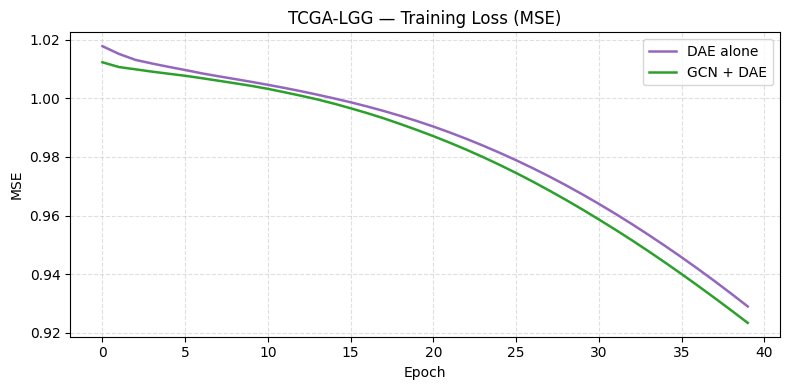

  Saved -> daegcn_lgg_latent.png


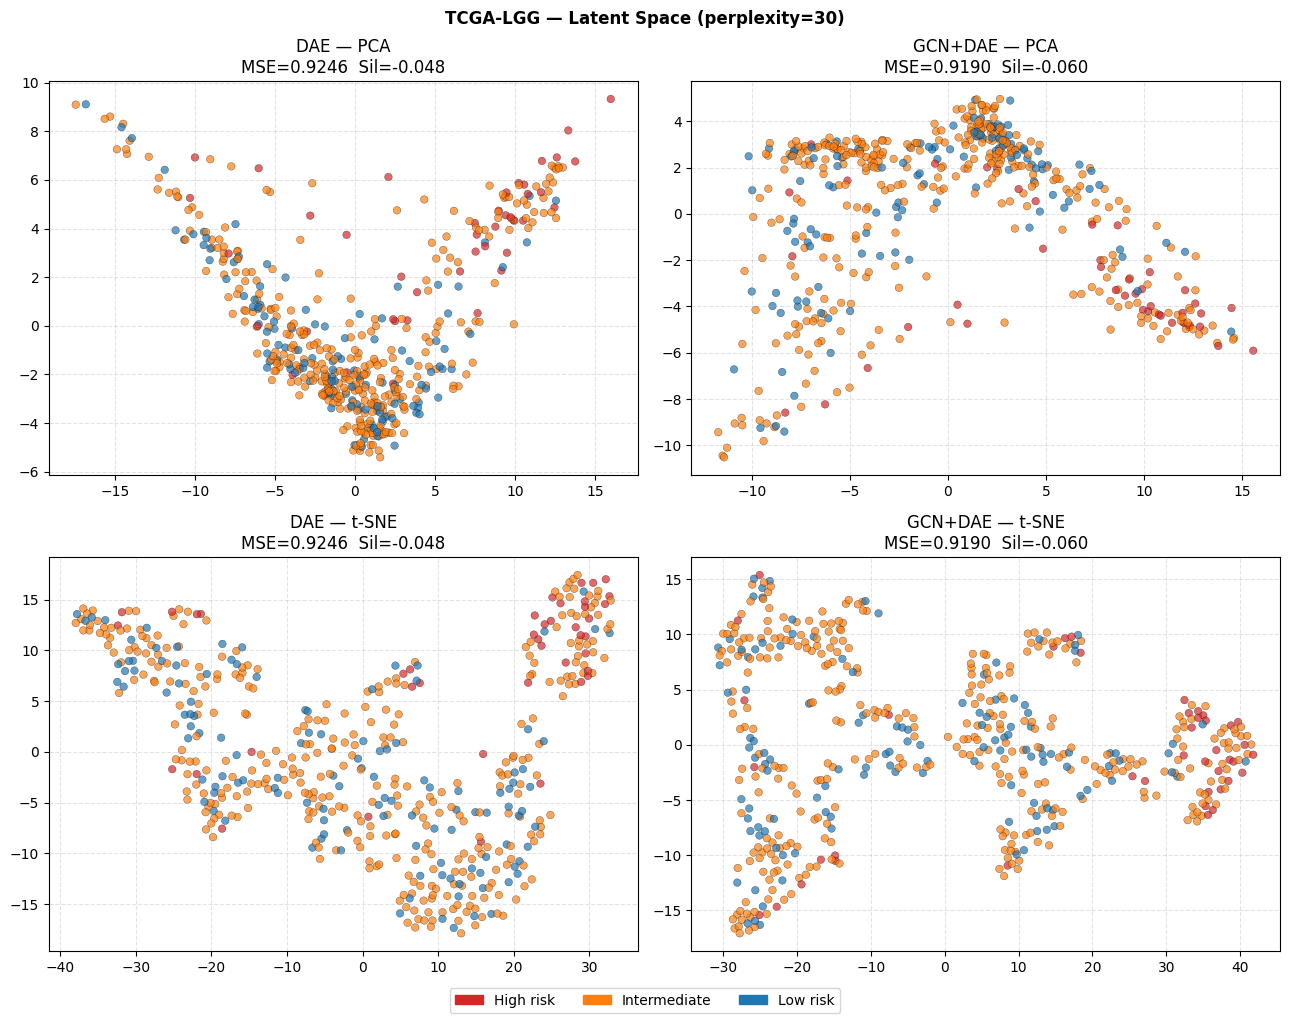

  Saved -> daegcn_lgg_recon_benefit.png


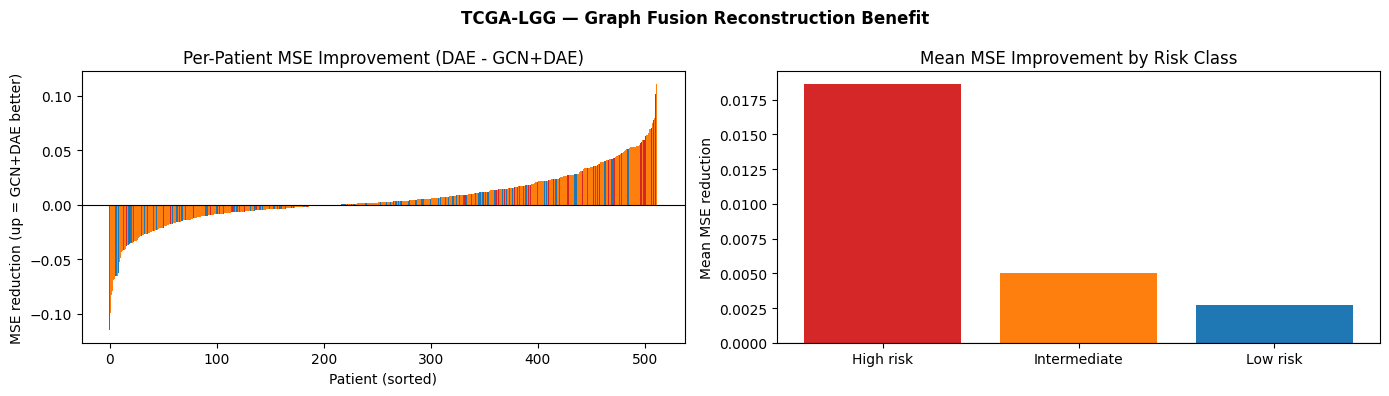

  Saved -> daegcn_lgg_km.png


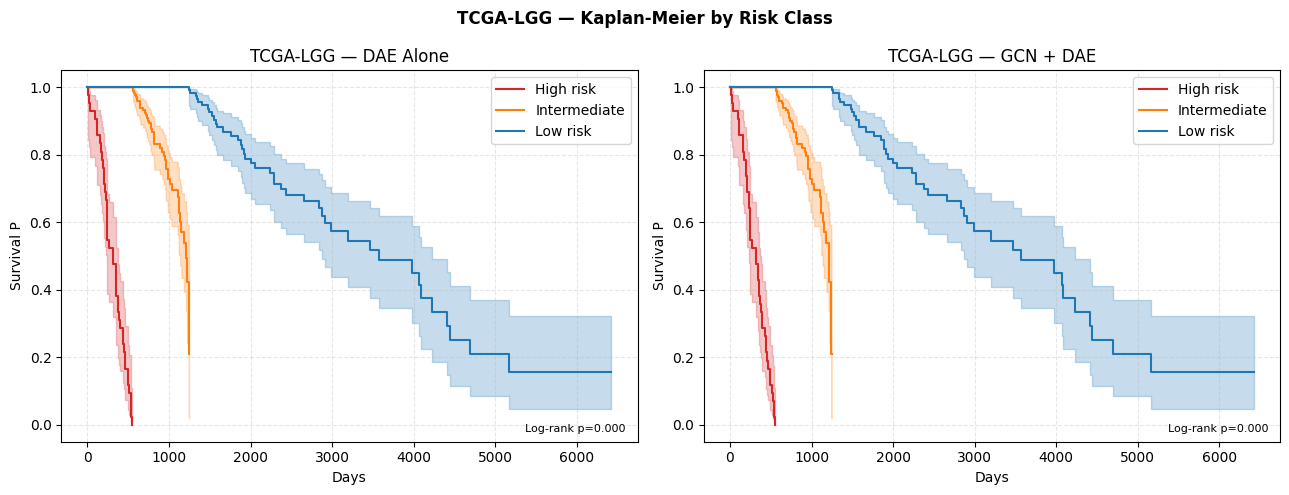

  Saved -> daegcn_lgg_heatmap.png


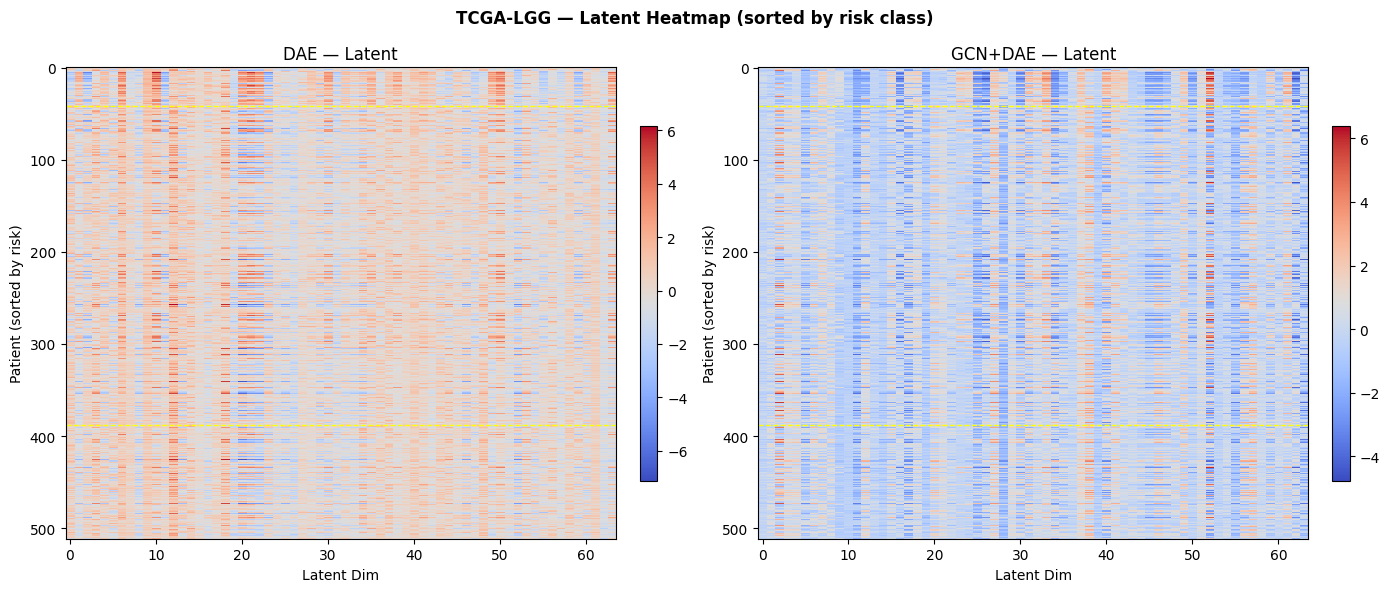

res1 freed.


In [6]:
# ==============================================================================
# CELL 4: TCGA-LGG — FIGURES
# RAM fix: del projections after latent plot; del res1 at end of cell
# ==============================================================================

# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res1['losses_dae'],    color='#9467bd', lw=1.8, label='DAE alone')
ax.plot(res1['losses_fusion'], color='#2ca02c', lw=1.8, label='GCN + DAE')
ax.set(title='TCGA-LGG — Training Loss (MSE)', xlabel='Epoch', ylabel='MSE')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); savefig('daegcn_lgg_loss.png')

# Latent space (PCA + t-SNE 2×2) — projections freed inside helper
plot_latent_space(res1, labels1, 'TCGA-LGG',
                  mse1_d, mse1_f, sil1_d, sil1_f, 'lgg')

# Per-patient reconstruction benefit
plot_recon_benefit(res1, labels1, 'TCGA-LGG', 'lgg')
res1['X_t'] = None; gc.collect()  # free scaled expression — no longer needed after recon_benefit

# Kaplan-Meier
plot_km(res1, labels1, t1, e1, 'TCGA-LGG', 'lgg')

# Latent heatmap
plot_heatmap(res1, labels1, t1, 'TCGA-LGG', 'lgg')

# Capture loss lists before freeing res (needed for Cell 11 combined loss figure)
losses1_dae    = res1['losses_dae']
losses1_fusion = res1['losses_fusion']

del res1; gc.collect()
print('res1 freed.')


### Cell 7 — TCGA-KIRC: Load, Preprocess, Build Graph & Train

In [7]:
# ==============================================================================
# CELL 5: TCGA-KIRC — LOAD, PREPROCESS, BUILD GRAPH, TRAIN
# RAM pattern: load -> filter -> scale -> del raw -> build adj -> train -> del intermediates
# ==============================================================================
X2_raw, t2, e2 = load_tcga_cohort(
    'TCGA-KIRC',
    COHORT_CONFIGS[1]['expr'],
    COHORT_CONFIGS[1]['surv'],
    top_n=TARGET_GENES,
)

scaler2    = StandardScaler()
X2_scaled  = scaler2.fit_transform(X2_raw)
del X2_raw; gc.collect()

X2_noisy = (X2_scaled
                  + NOISE_FACTOR * np.random.randn(*X2_scaled.shape).astype(np.float32))
labels2  = make_risk_labels(t2, e2)
A2       = build_knn_adj(X2_scaled, k=min(K_NN, len(X2_scaled)//4))

counts = np.bincount(labels2)
print('Risk label distribution (TCGA-KIRC):')
for k, nm in RISK_LABELS.items():
    print(f'  Class {k} ({nm}): {counts[k]}')

res2 = train_models(X2_scaled, X2_noisy, A2,
                          latent_dim=LATENT_DIM, epochs=EPOCHS, lr=LR, hidden=HIDDEN_DIM)
del X2_noisy, A2; gc.collect()

mse2_d, mse2_f, sil2_d, sil2_f, con2_d, con2_f = \
    compute_metrics(res2, labels2)

print_metrics('TCGA-KIRC', mse2_d, mse2_f,
              sil2_d, sil2_f, con2_d, con2_f)
save_embeddings(res2, labels2, t2, e2, 'kirc')

# ── Checkpoint: save both model weights before freeing res ────────────────
torch.save({
    'state_dae':    res2['state_dae'],
    'state_fusion': res2['state_fusion'],
    'model_config': res2['model_config'],
    'cohort':       'kirc',
    'pipeline_stage': PIPELINE_STAGE,
    'metrics': {
        'mse_dae':    mse2_d, 'mse_fusion':    mse2_f,
        'sil_dae':    sil2_d, 'sil_fusion':    sil2_f,
        'con_dae':    con2_d, 'con_fusion':    con2_f,
    },
}, CHECKPOINT_DIR / f'NB05_kirc_dae_gcn.pt')
print(f'  💾 NB05_kirc_dae_gcn.pt')
del res2['state_dae'], res2['state_fusion']; gc.collect()

n2_patients = len(X2_scaled)
n2_features = X2_scaled.shape[1]
del X2_scaled; gc.collect()


Loading TCGA-KIRC ...
  Loading  : TCGA-KIRC.star_fpkm.tsv  (204.3 MB)
  TCGA-KIRC: 531 patients | 3,000 genes | 175 events (33.0%) | RAM: 6.4 MB
Risk label distribution (TCGA-KIRC):
  Class 0 (High risk): 58
  Class 1 (Intermediate): 205
  Class 2 (Low risk): 268
TCGA-KIRC RESULTS
Metric                            DAE    GCN+DAE
----------------------------------------------------
MSE                            0.9551     0.9577
Silhouette                    -0.0151    -0.0236
Concordance proxy              0.0440     0.0526
  📁 NB05_kirc_dae_fullcohort_latents.csv  (full-cohort scaler — representation only)
  📁 NB05_kirc_gcndae_fullcohort_latents.csv  (full-cohort scaler — representation only)
  💾 NB05_kirc_dae_gcn.pt


0

### Cell 8 — TCGA-KIRC: Figures

  Saved -> daegcn_kirc_loss.png


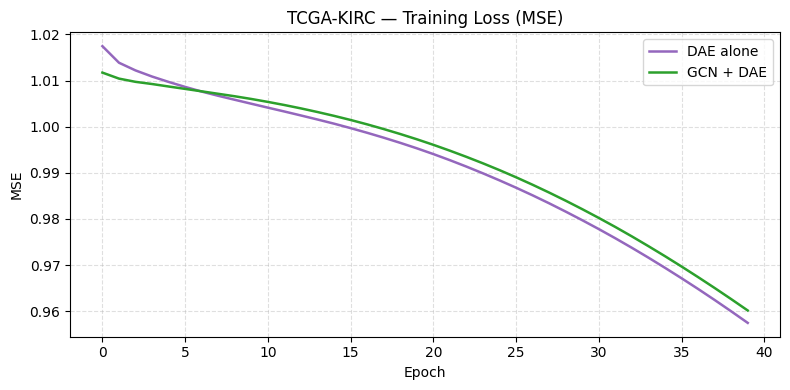

  Saved -> daegcn_kirc_latent.png


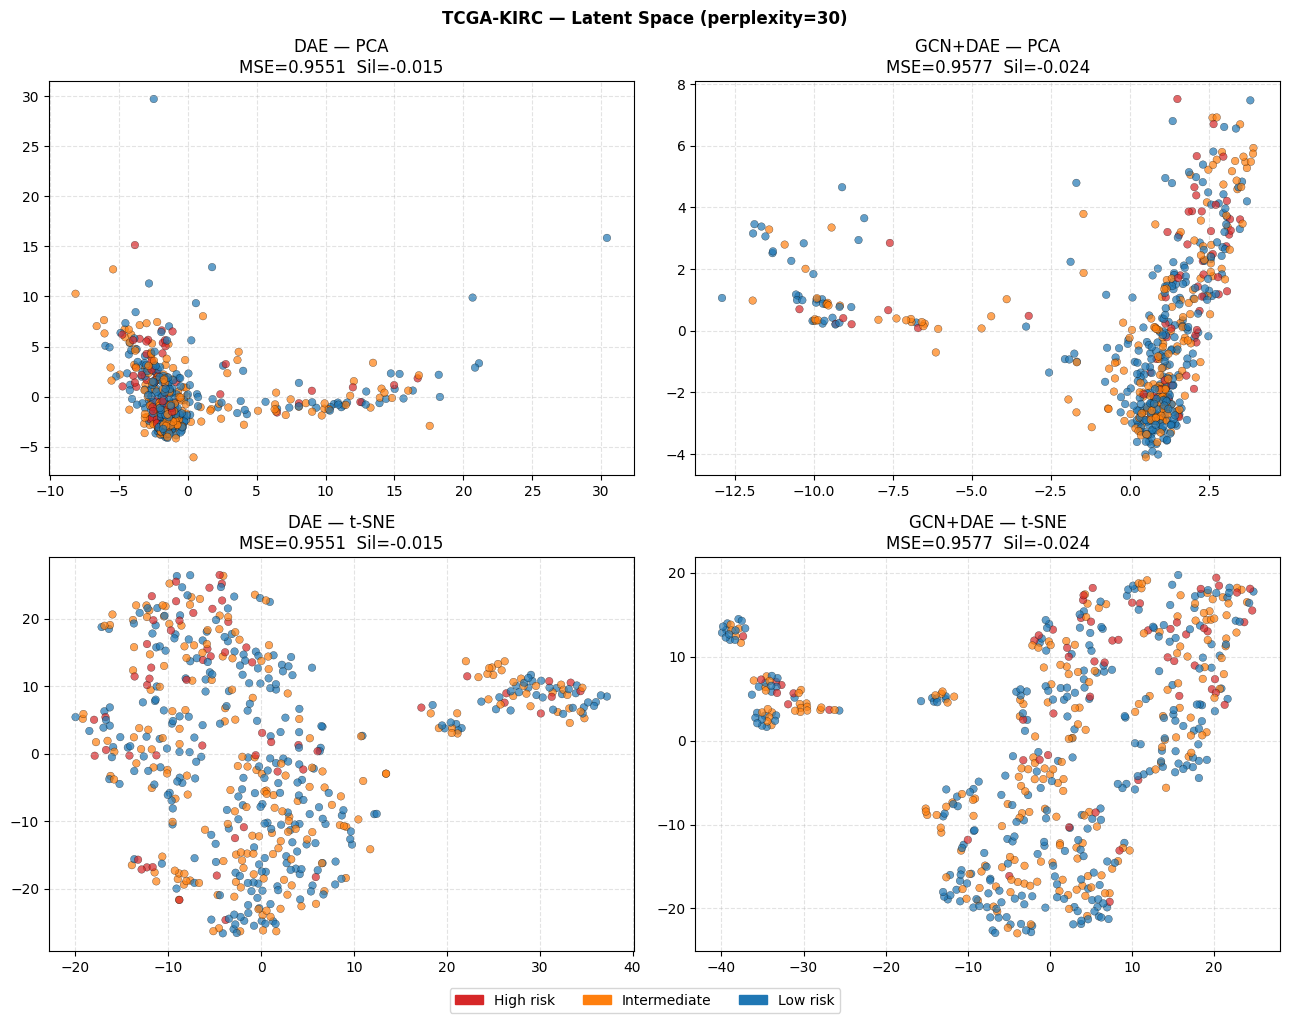

  Saved -> daegcn_kirc_recon_benefit.png


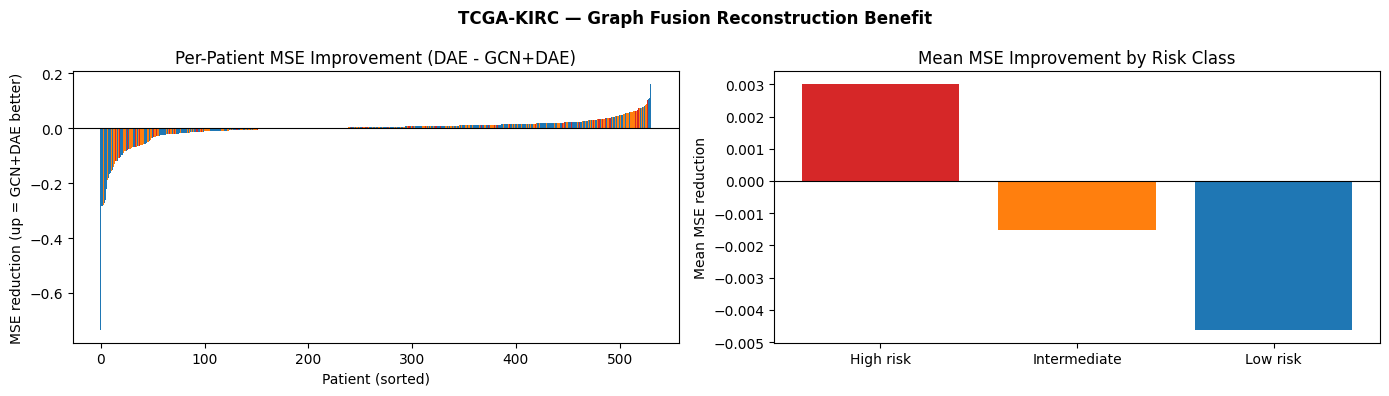

  Saved -> daegcn_kirc_km.png


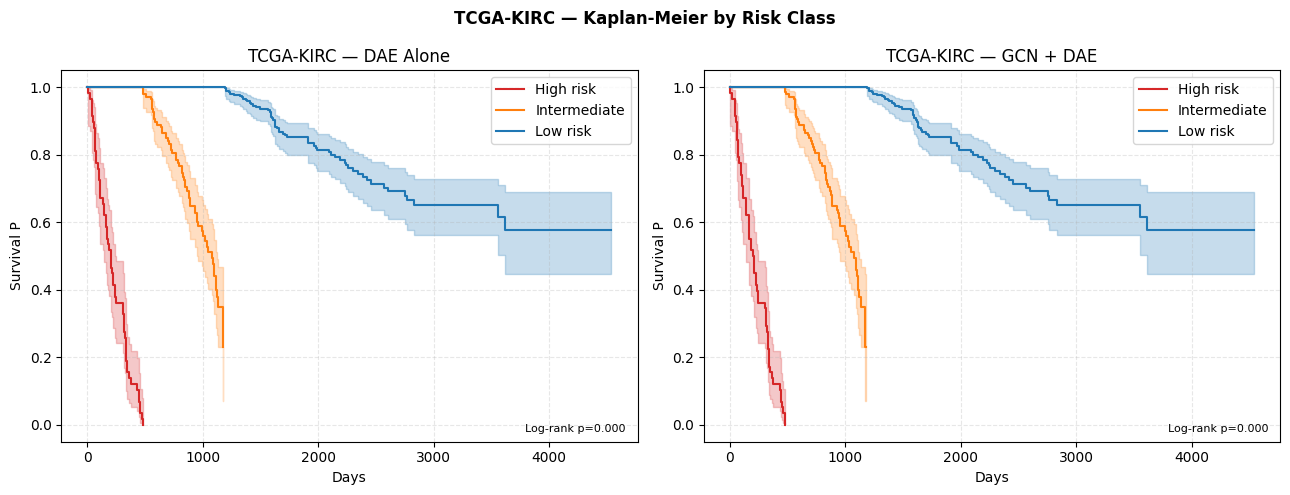

  Saved -> daegcn_kirc_heatmap.png


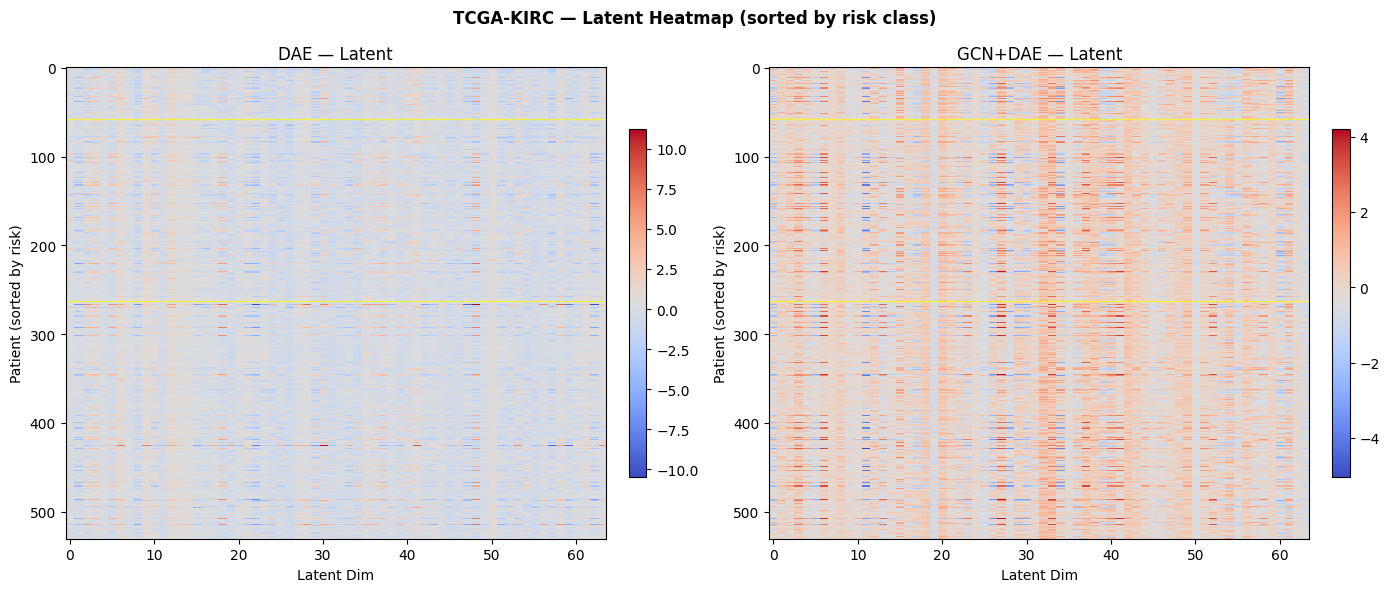

res2 freed.


In [8]:
# ==============================================================================
# CELL 6: TCGA-KIRC — FIGURES
# RAM fix: del projections after latent plot; del res2 at end of cell
# ==============================================================================

# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res2['losses_dae'],    color='#9467bd', lw=1.8, label='DAE alone')
ax.plot(res2['losses_fusion'], color='#2ca02c', lw=1.8, label='GCN + DAE')
ax.set(title='TCGA-KIRC — Training Loss (MSE)', xlabel='Epoch', ylabel='MSE')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); savefig('daegcn_kirc_loss.png')

# Latent space (PCA + t-SNE 2×2) — projections freed inside helper
plot_latent_space(res2, labels2, 'TCGA-KIRC',
                  mse2_d, mse2_f, sil2_d, sil2_f, 'kirc')

# Per-patient reconstruction benefit
plot_recon_benefit(res2, labels2, 'TCGA-KIRC', 'kirc')
res2['X_t'] = None; gc.collect()  # free scaled expression — no longer needed after recon_benefit

# Kaplan-Meier
plot_km(res2, labels2, t2, e2, 'TCGA-KIRC', 'kirc')

# Latent heatmap
plot_heatmap(res2, labels2, t2, 'TCGA-KIRC', 'kirc')

# Capture loss lists before freeing res (needed for Cell 11 combined loss figure)
losses2_dae    = res2['losses_dae']
losses2_fusion = res2['losses_fusion']

del res2; gc.collect()
print('res2 freed.')


### Cell 9 — TCGA-LUAD: Load, Preprocess, Build Graph & Train

In [9]:
# ==============================================================================
# CELL 7: TCGA-LUAD — LOAD, PREPROCESS, BUILD GRAPH, TRAIN
# RAM pattern: load -> filter -> scale -> del raw -> build adj -> train -> del intermediates
# ==============================================================================
X3_raw, t3, e3 = load_tcga_cohort(
    'TCGA-LUAD',
    COHORT_CONFIGS[2]['expr'],
    COHORT_CONFIGS[2]['surv'],
    top_n=TARGET_GENES,
)

scaler3    = StandardScaler()
X3_scaled  = scaler3.fit_transform(X3_raw)
del X3_raw; gc.collect()

X3_noisy = (X3_scaled
                  + NOISE_FACTOR * np.random.randn(*X3_scaled.shape).astype(np.float32))
labels3  = make_risk_labels(t3, e3)
A3       = build_knn_adj(X3_scaled, k=min(K_NN, len(X3_scaled)//4))

counts = np.bincount(labels3)
print('Risk label distribution (TCGA-LUAD):')
for k, nm in RISK_LABELS.items():
    print(f'  Class {k} ({nm}): {counts[k]}')

res3 = train_models(X3_scaled, X3_noisy, A3,
                          latent_dim=LATENT_DIM, epochs=EPOCHS, lr=LR, hidden=HIDDEN_DIM)
del X3_noisy, A3; gc.collect()

mse3_d, mse3_f, sil3_d, sil3_f, con3_d, con3_f = \
    compute_metrics(res3, labels3)

print_metrics('TCGA-LUAD', mse3_d, mse3_f,
              sil3_d, sil3_f, con3_d, con3_f)
save_embeddings(res3, labels3, t3, e3, 'luad')

# ── Checkpoint: save both model weights before freeing res ────────────────
torch.save({
    'state_dae':    res3['state_dae'],
    'state_fusion': res3['state_fusion'],
    'model_config': res3['model_config'],
    'cohort':       'luad',
    'pipeline_stage': PIPELINE_STAGE,
    'metrics': {
        'mse_dae':    mse3_d, 'mse_fusion':    mse3_f,
        'sil_dae':    sil3_d, 'sil_fusion':    sil3_f,
        'con_dae':    con3_d, 'con_fusion':    con3_f,
    },
}, CHECKPOINT_DIR / f'NB05_luad_dae_gcn.pt')
print(f'  💾 NB05_luad_dae_gcn.pt')
del res3['state_dae'], res3['state_fusion']; gc.collect()

n3_patients = len(X3_scaled)
n3_features = X3_scaled.shape[1]
del X3_scaled; gc.collect()


Loading TCGA-LUAD ...
  Loading  : TCGA-LUAD.star_fpkm.tsv  (199.0 MB)
  TCGA-LUAD: 504 patients | 3,000 genes | 182 events (36.1%) | RAM: 6.0 MB
Risk label distribution (TCGA-LUAD):
  Class 0 (High risk): 60
  Class 1 (Intermediate): 280
  Class 2 (Low risk): 164
TCGA-LUAD RESULTS
Metric                            DAE    GCN+DAE
----------------------------------------------------
MSE                            0.9721     0.9704
Silhouette                     0.0028    -0.0275
Concordance proxy              0.0179     0.0528
  📁 NB05_luad_dae_fullcohort_latents.csv  (full-cohort scaler — representation only)
  📁 NB05_luad_gcndae_fullcohort_latents.csv  (full-cohort scaler — representation only)
  💾 NB05_luad_dae_gcn.pt


0

### Cell 10 — TCGA-LUAD: Figures

  Saved -> daegcn_luad_loss.png


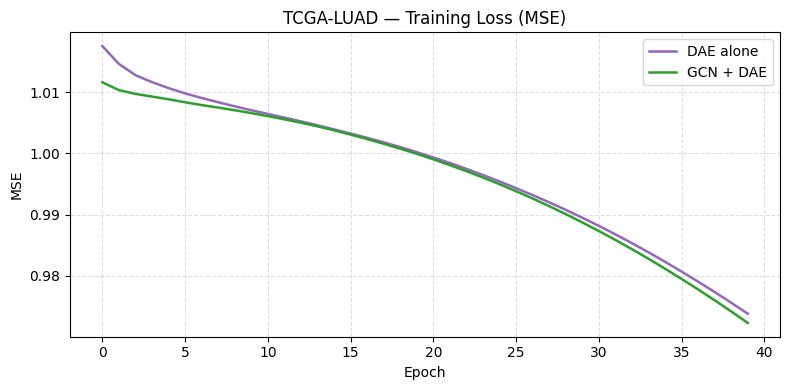

  Saved -> daegcn_luad_latent.png


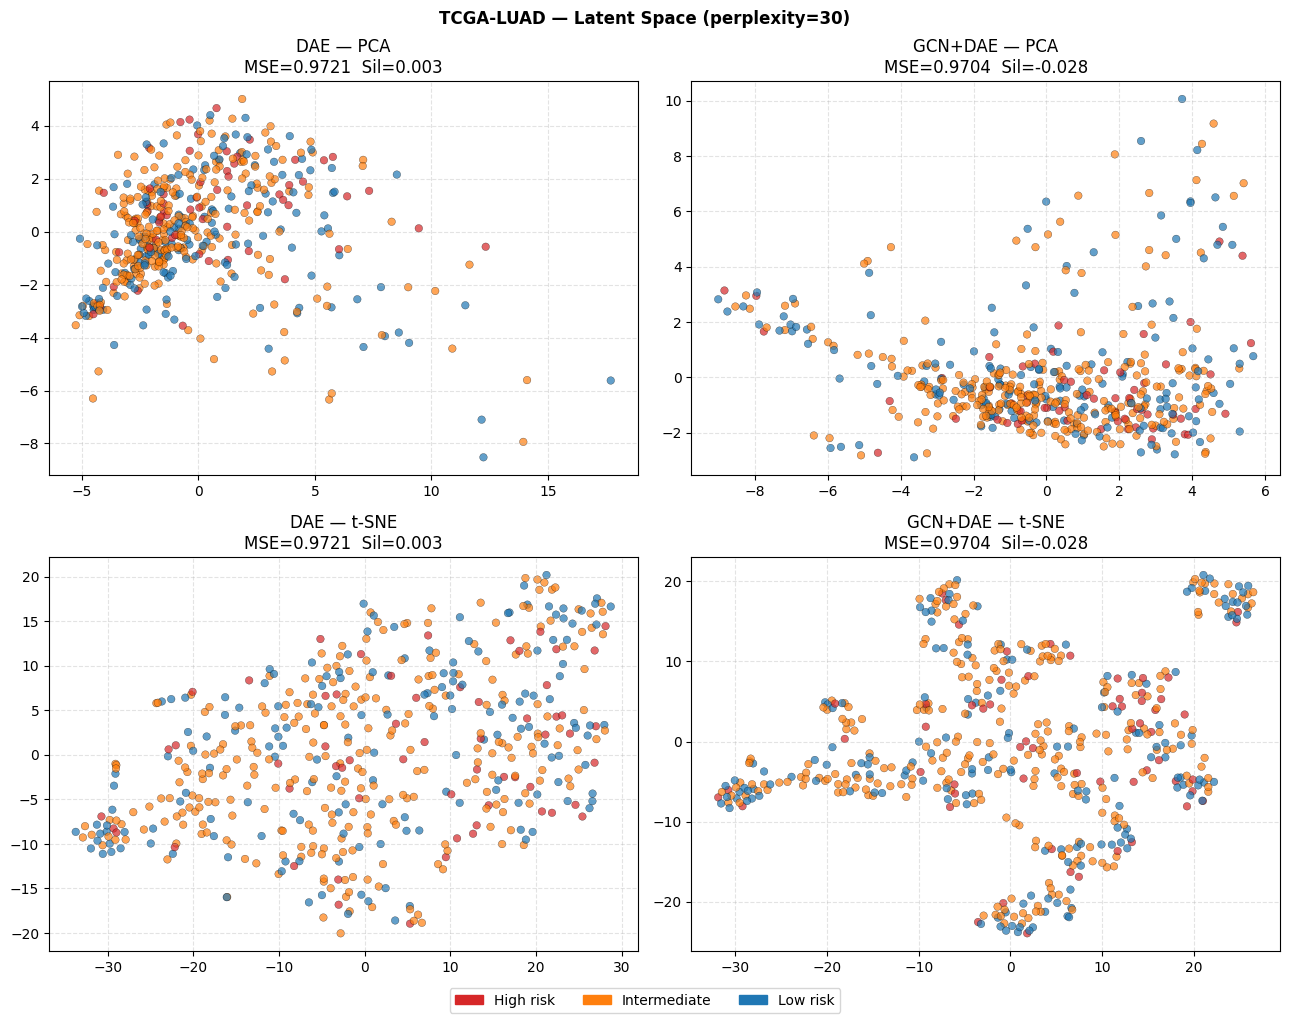

  Saved -> daegcn_luad_recon_benefit.png


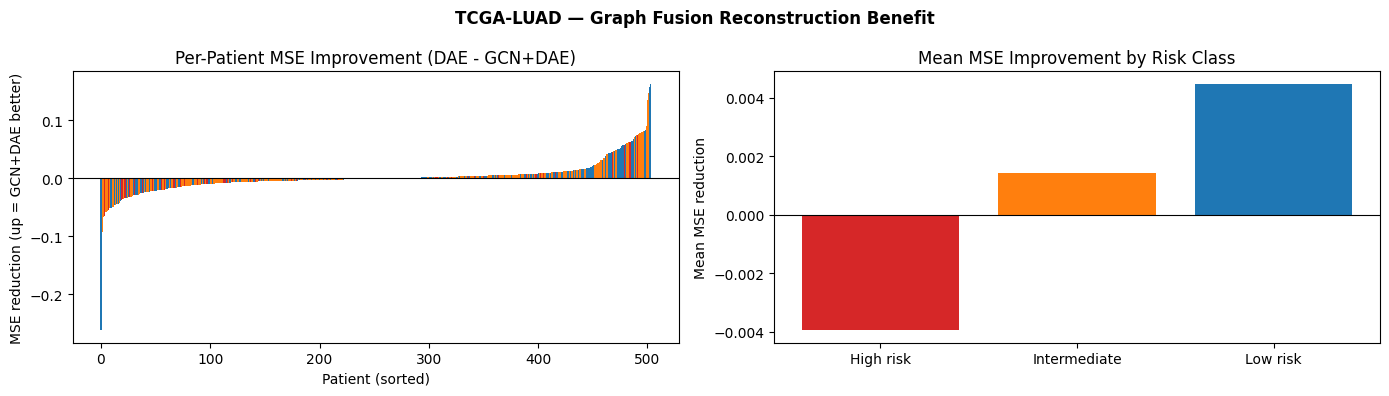

  Saved -> daegcn_luad_km.png


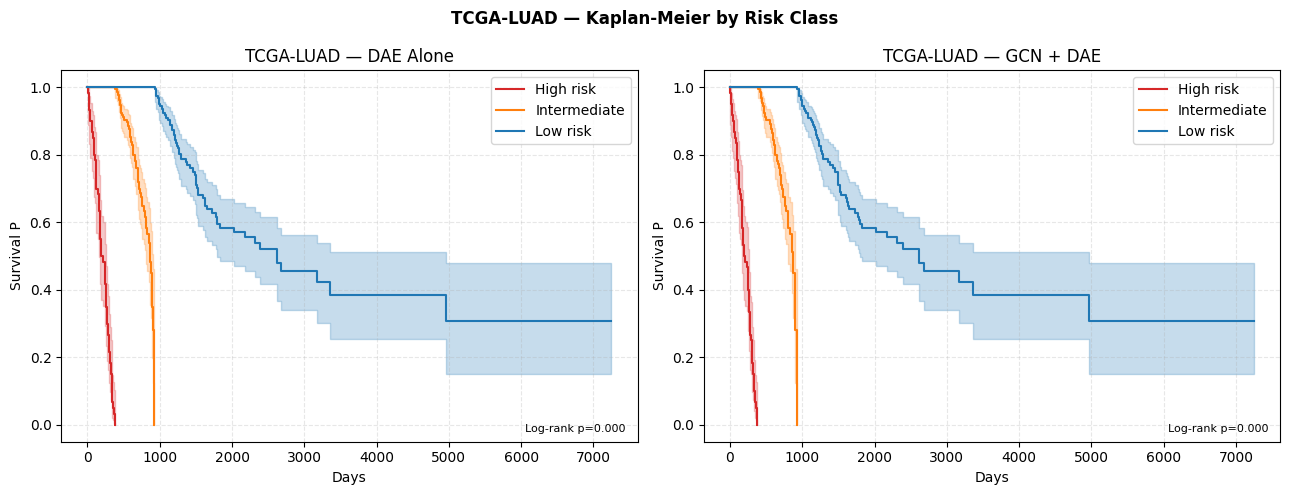

  Saved -> daegcn_luad_heatmap.png


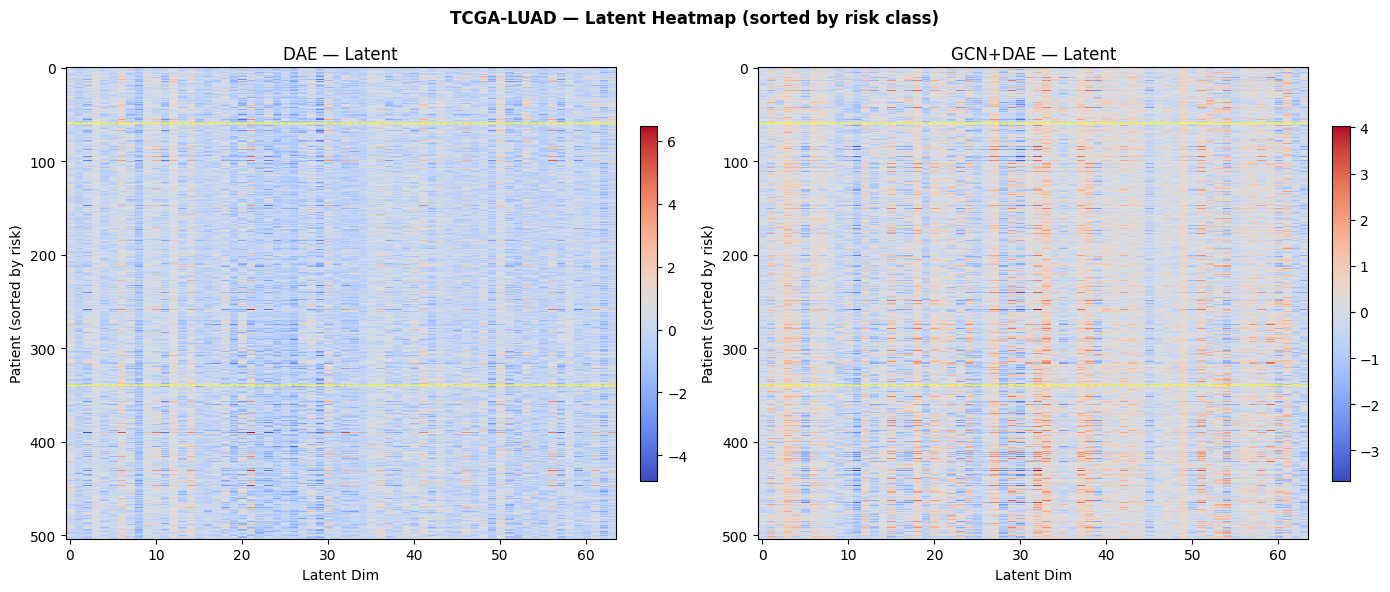

res3 freed.


In [10]:
# ==============================================================================
# CELL 8: TCGA-LUAD — FIGURES
# RAM fix: del projections after latent plot; del res3 at end of cell
# ==============================================================================

# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res3['losses_dae'],    color='#9467bd', lw=1.8, label='DAE alone')
ax.plot(res3['losses_fusion'], color='#2ca02c', lw=1.8, label='GCN + DAE')
ax.set(title='TCGA-LUAD — Training Loss (MSE)', xlabel='Epoch', ylabel='MSE')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); savefig('daegcn_luad_loss.png')

# Latent space (PCA + t-SNE 2×2) — projections freed inside helper
plot_latent_space(res3, labels3, 'TCGA-LUAD',
                  mse3_d, mse3_f, sil3_d, sil3_f, 'luad')

# Per-patient reconstruction benefit
plot_recon_benefit(res3, labels3, 'TCGA-LUAD', 'luad')
res3['X_t'] = None; gc.collect()  # free scaled expression — no longer needed after recon_benefit

# Kaplan-Meier
plot_km(res3, labels3, t3, e3, 'TCGA-LUAD', 'luad')

# Latent heatmap
plot_heatmap(res3, labels3, t3, 'TCGA-LUAD', 'luad')

# Capture loss lists before freeing res (needed for Cell 11 combined loss figure)
losses3_dae    = res3['losses_dae']
losses3_fusion = res3['losses_fusion']

del res3; gc.collect()
print('res3 freed.')


### Cell 11 — Cross-Cohort Summary Figures

All three cohorts share the same 3000-gene HVG feature space (STAR FPKM, GRCh38),
so **cross-cohort MSE comparison is meaningful here** — unlike v1.0/v1.1 which mixed
genomics with clinical tabular data.


  Saved -> daegcn_summary_metrics.png


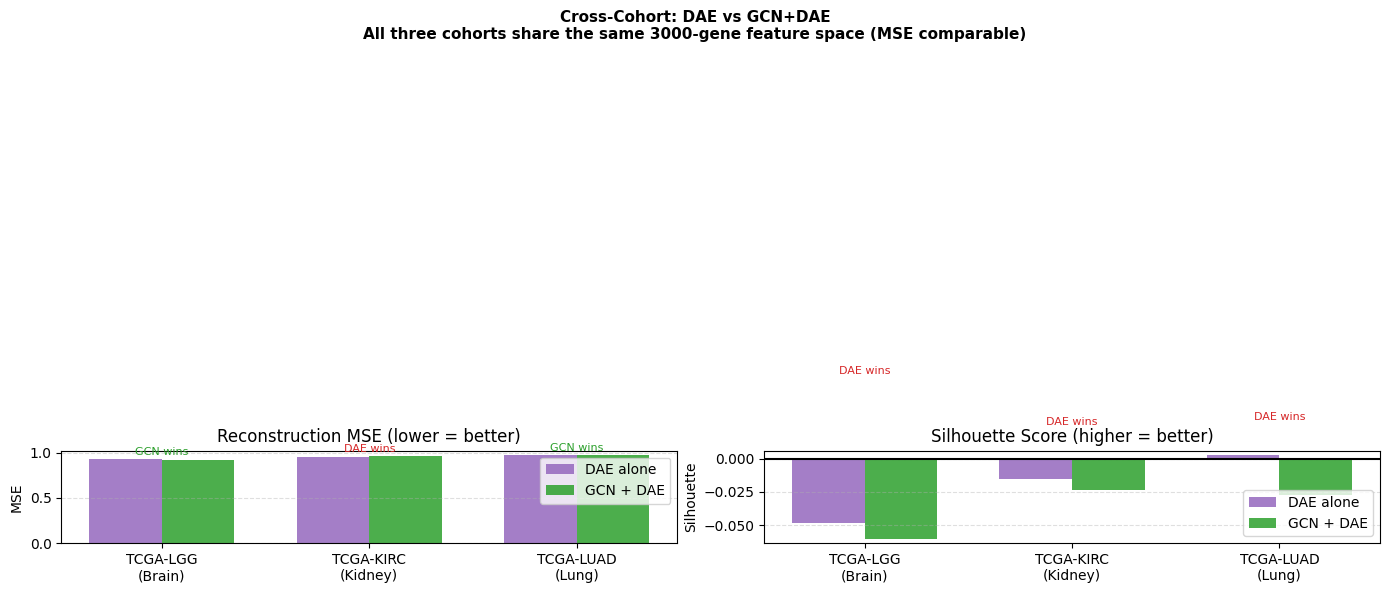

  Saved -> daegcn_summary_loss_all.png


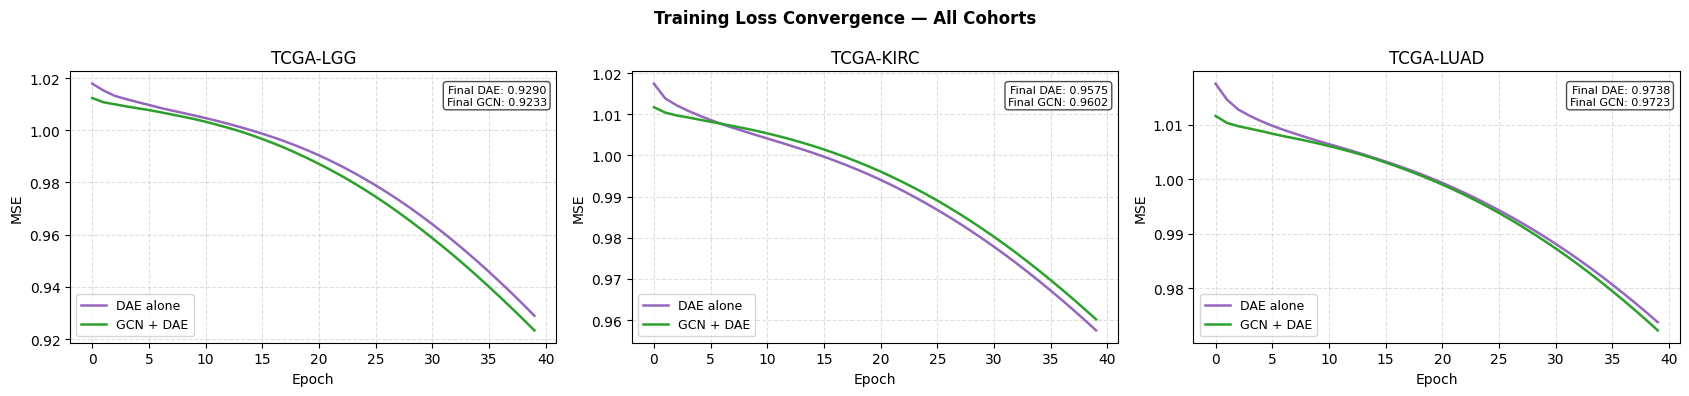

  Saved -> daegcn_summary_distributions.png


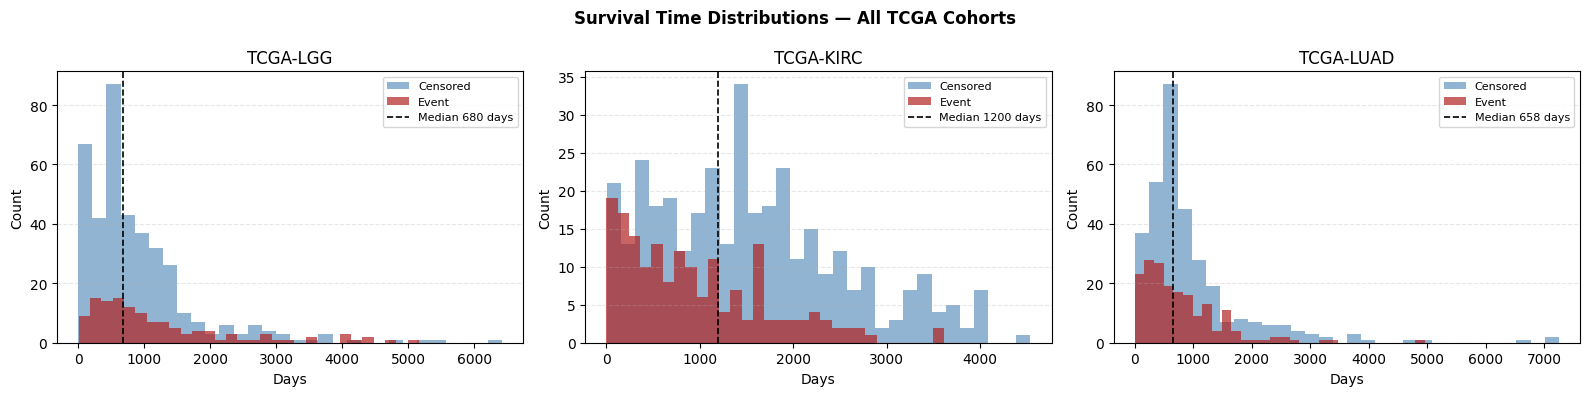

  Saved -> daegcn_summary_concordance.png


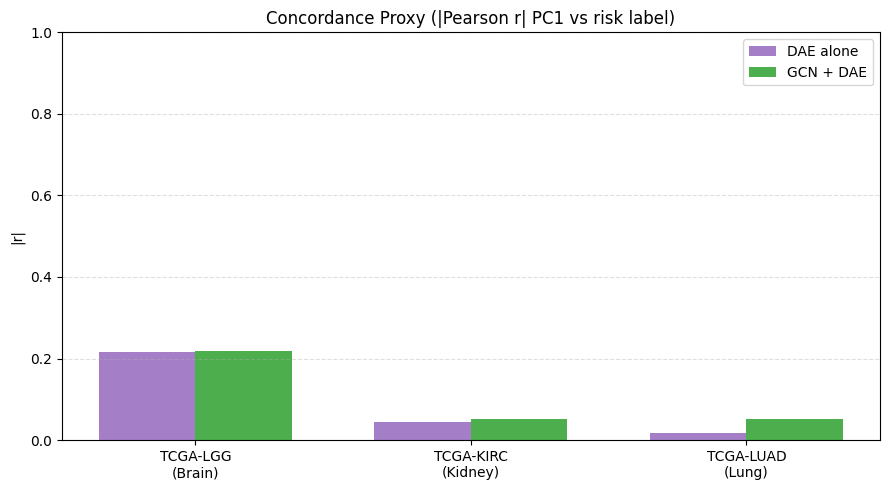

  Saved -> daegcn_summary_radar.png


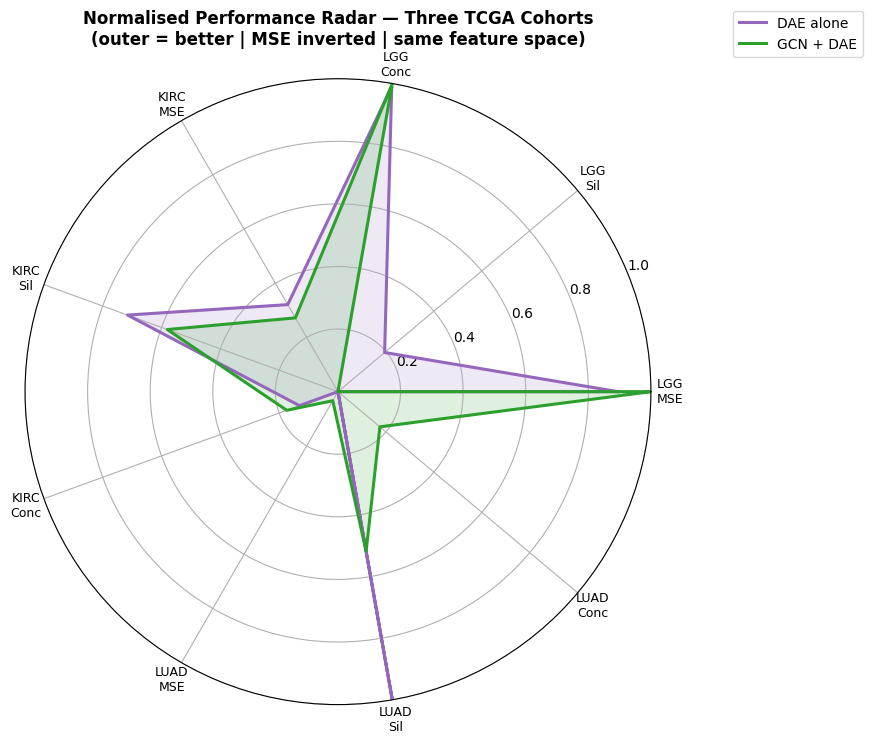

In [11]:
# ==============================================================================
# CELL 11: CROSS-COHORT SUMMARY FIGURES
# res1/2/3 already freed. Uses only scalar metrics + captured loss lists.
# ==============================================================================
dataset_labels = ['TCGA-LGG\n(Brain)', 'TCGA-KIRC\n(Kidney)', 'TCGA-LUAD\n(Lung)']
colors_bar     = [COHORT_COLORS[c['name']] for c in COHORT_CONFIGS]

mse_dae    = [mse1_d,  mse2_d,  mse3_d]
mse_fusion = [mse1_f,  mse2_f,  mse3_f]
sil_dae    = [sil1_d,  sil2_d,  sil3_d]
sil_fusion = [sil1_f,  sil2_f,  sil3_f]
con_dae    = [con1_d,  con2_d,  con3_d]
con_fusion = [con1_f,  con2_f,  con3_f]

x, w = np.arange(3), 0.35

# Fig: MSE + Silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dae_v, fus_v, title, ylabel, invert in [
    (axes[0], mse_dae, mse_fusion, 'Reconstruction MSE (lower = better)', 'MSE', True),
    (axes[1], sil_dae, sil_fusion, 'Silhouette Score (higher = better)',  'Silhouette', False),
]:
    ax.bar(x - w/2, dae_v, w, label='DAE alone', color='#9467bd', alpha=0.85)
    ax.bar(x + w/2, fus_v, w, label='GCN + DAE', color='#2ca02c', alpha=0.85)
    if not invert:
        ax.axhline(0, color='k', lw=1.5, zorder=5)
    ax.set(title=title, ylabel=ylabel, xticks=x, xticklabels=dataset_labels)
    ax.legend(); ax.grid(True, ls='--', alpha=0.4, axis='y')
    for i, (a, b) in enumerate(zip(dae_v, fus_v)):
        win = b < a if invert else b > a
        best = max(abs(a), abs(b))
        ax.text(i, best * 1.05, ('GCN wins' if win else 'DAE wins'),
                ha='center', fontsize=8, color='#2ca02c' if win else '#d62728')
fig.suptitle('Cross-Cohort: DAE vs GCN+DAE\n'
             'All three cohorts share the same 3000-gene feature space (MSE comparable)',
             fontweight='bold', fontsize=11)
plt.tight_layout(); savefig('daegcn_summary_metrics.png')

# Fig: All loss curves
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
for ax, (name, ld, lf) in zip(axes, [
    ('TCGA-LGG',  losses1_dae, losses1_fusion),
    ('TCGA-KIRC', losses2_dae, losses2_fusion),
    ('TCGA-LUAD', losses3_dae, losses3_fusion),
]):
    ax.plot(ld, color='#9467bd', lw=1.8, label='DAE alone')
    ax.plot(lf, color='#2ca02c', lw=1.8, label='GCN + DAE')
    ax.set(title=name, xlabel='Epoch', ylabel='MSE')
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.4)
    ax.text(0.98, 0.95,
            f'Final DAE: {ld[-1]:.4f}\nFinal GCN: {lf[-1]:.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
fig.suptitle('Training Loss Convergence — All Cohorts', fontweight='bold')
plt.tight_layout(); savefig('daegcn_summary_loss_all.png')

# Fig: Survival time distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (times, events, name) in zip(axes, [
    (t1, e1, 'TCGA-LGG'),
    (t2, e2, 'TCGA-KIRC'),
    (t3, e3, 'TCGA-LUAD'),
]):
    ax.hist(times[events==0], bins=30, alpha=0.6, color='steelblue', label='Censored')
    ax.hist(times[events==1], bins=30, alpha=0.7, color='firebrick', label='Event')
    ax.axvline(np.median(times), color='k', ls='--', lw=1.2,
               label=f'Median {np.median(times):.0f} days')
    ax.set(title=name, xlabel='Days', ylabel='Count')
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.3, axis='y')
fig.suptitle('Survival Time Distributions — All TCGA Cohorts', fontweight='bold')
plt.tight_layout(); savefig('daegcn_summary_distributions.png')

# Fig: Concordance proxy grouped bar
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, con_dae,    w, label='DAE alone', color='#9467bd', alpha=0.85)
ax.bar(x + w/2, con_fusion, w, label='GCN + DAE', color='#2ca02c', alpha=0.85)
ax.set(title='Concordance Proxy (|Pearson r| PC1 vs risk label)',
       ylabel='|r|', xticks=x, xticklabels=dataset_labels)
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, ls='--', alpha=0.4, axis='y')
plt.tight_layout(); savefig('daegcn_summary_concordance.png')

# Fig: Radar chart
def norm_range(vals, v, invert=False):
    lo, hi = min(vals), max(vals)
    n = (v - lo) / (hi - lo + 1e-9)
    return 1 - n if invert else n

all_mse = mse_dae + mse_fusion
all_sil = sil_dae + sil_fusion
all_con = con_dae + con_fusion

cats = ['LGG\nMSE','LGG\nSil','LGG\nConc',
        'KIRC\nMSE','KIRC\nSil','KIRC\nConc',
        'LUAD\nMSE','LUAD\nSil','LUAD\nConc']

v_d = [norm_range(all_mse,mse1_d,True), norm_range(all_sil,sil1_d),   norm_range(all_con,con1_d),
       norm_range(all_mse,mse2_d,True), norm_range(all_sil,sil2_d),   norm_range(all_con,con2_d),
       norm_range(all_mse,mse3_d,True), norm_range(all_sil,sil3_d),   norm_range(all_con,con3_d)]
v_f = [norm_range(all_mse,mse1_f,True), norm_range(all_sil,sil1_f),   norm_range(all_con,con1_f),
       norm_range(all_mse,mse2_f,True), norm_range(all_sil,sil2_f),   norm_range(all_con,con2_f),
       norm_range(all_mse,mse3_f,True), norm_range(all_sil,sil3_f),   norm_range(all_con,con3_f)]

N      = len(cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]; v_d += v_d[:1]; v_f += v_f[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles, v_d, color='#9467bd', lw=2.2, label='DAE alone')
ax.fill(angles, v_d, color='#9467bd', alpha=0.15)
ax.plot(angles, v_f, color='#2ca02c', lw=2.2, label='GCN + DAE')
ax.fill(angles, v_f, color='#2ca02c', alpha=0.15)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, fontsize=9); ax.set_ylim(0, 1)
ax.set_title('Normalised Performance Radar — Three TCGA Cohorts\n'
             '(outer = better | MSE inverted | same feature space)',
             fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12))
plt.tight_layout(); savefig('daegcn_summary_radar.png')


### Cell 12 — Master Summary Table

In [12]:
# ==============================================================================
# CELL 12: MASTER SUMMARY TABLE
# ==============================================================================
summary = pd.DataFrame({
    'Cohort':      ['TCGA-LGG',  'TCGA-LGG',
                    'TCGA-KIRC', 'TCGA-KIRC',
                    'TCGA-LUAD', 'TCGA-LUAD'],
    'Model':       ['DAE', 'GCN+DAE'] * 3,
    'MSE':         [mse1_d, mse1_f, mse2_d, mse2_f, mse3_d, mse3_f],
    'Silhouette':  [sil1_d, sil1_f, sil2_d, sil2_f, sil3_d, sil3_f],
    'Concordance': [con1_d, con1_f, con2_d, con2_f, con3_d, con3_f],
    'Patients':    [n1_patients]*2 + [n2_patients]*2 + [n3_patients]*2,
    'Features':    [n1_features]*2 + [n2_features]*2 + [n3_features]*2,
})

print('\n' + '='*80)
print('MASTER EVALUATION SUMMARY — DAE vs GCN+DAE (all real TCGA)')
print('='*80)
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('='*80)

print('\nEmbeddings written to:', EMBEDDINGS_DIR)
for f in sorted(EMBEDDINGS_DIR.glob('*.csv')):
    df_check = pd.read_csv(f)
    print(f'  {f.name:<45}  shape={df_check.shape}')

print(f"""
{'='*65}
  PIPELINE CONTEXT
{'='*65}
  All three cohorts use the same feature space:
    top-{TARGET_GENES} variance-filtered HVGs from STAR FPKM (GRCh38).
  Cross-cohort MSE comparison is therefore meaningful (v1.0 was not).

  NB04 (Pathway-GCN) comparison reference:
    NB04 uses pathway-informed graph topology + discrete hazard head
    evaluated by survival C-index.
    This notebook uses unsupervised k-NN graphs evaluated by
    reconstruction MSE and silhouette score — different objectives.

  Design notes:
    DAE and GCN+DAE have matched parameter counts (hidden={HIDDEN_DIM}).
    Silhouette < 0 is expected: risk classes derived from continuous
    survival times have natural overlap.
    Concordance (|r| PC1 vs risk label) is a rank-ordering proxy.
    Embeddings saved separately per model and cohort.

__OUTPUTS_PLACEHOLDER__
{'='*65}
""")

# Dynamic output listing
print('\n  Embeddings written:')
for _c in COHORT_CONFIGS:
    for _m in ('dae', 'gcndae'):
        _p = EMBEDDINGS_DIR / f'{_c["cid"]}_{_m}_latents.csv'
        _ok = '✅' if _p.exists() else '❌'
        print(f'  {_ok} {_p.relative_to(BASE_DIR)}')
print(f'  Figures → {FIGURES_DIR.relative_to(BASE_DIR)}/daegcn_*.png')


MASTER EVALUATION SUMMARY — DAE vs GCN+DAE (all real TCGA)
   Cohort   Model    MSE  Silhouette  Concordance  Patients  Features
 TCGA-LGG     DAE 0.9246     -0.0479       0.2152       512      3000
 TCGA-LGG GCN+DAE 0.9190     -0.0601       0.2173       512      3000
TCGA-KIRC     DAE 0.9551     -0.0151       0.0440       531      3000
TCGA-KIRC GCN+DAE 0.9577     -0.0236       0.0526       531      3000
TCGA-LUAD     DAE 0.9721      0.0028       0.0179       504      3000
TCGA-LUAD GCN+DAE 0.9704     -0.0275       0.0528       504      3000

Embeddings written to: D:\JupyterWork\NB04\embeddings\NB05
  gbsg2_dae_latents.csv                          shape=(686, 67)
  gbsg2_gcndae_latents.csv                       shape=(686, 67)
  lgg_dae_latents.csv                            shape=(512, 67)
  lgg_gcndae_latents.csv                         shape=(512, 67)
  NB05_kirc_dae_fullcohort_latents.csv           shape=(531, 67)
  NB05_kirc_gcndae_fullcohort_latents.csv        shape=(531, 67)
